# Unemployment Analysis with Python

## 1. Introduction

This project analyzes unemployment trends in India using historical unemployment data.

The analysis focuses on regional differences, monthly trends, labour participation, employment levels, and changes around the COVID-19 period.

The project includes data cleaning, exploratory data analysis, visualization, regional analysis, correlation analysis, and pre-COVID versus post-COVID comparison.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [34]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 2. Dataset Overview

Before performing analysis, we inspect the size and structure of the dataset.

In [35]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 768
Number of columns: 7


In [36]:
print("Columns in the dataset:")

for column in df.columns:
    print(column)
    

Columns in the dataset:
Region
 Date
 Frequency
 Estimated Unemployment Rate (%)
 Estimated Employed
 Estimated Labour Participation Rate (%)
Area


In [37]:
df.columns = df.columns.str.strip()

df.columns


Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [39]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [40]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 27


In [41]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (741, 7)


In [42]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

print(df["Date"].min())
print(df["Date"].max())

2019-05-31 00:00:00
2020-06-30 00:00:00


In [43]:
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df[numeric_columns].dtypes

Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
dtype: object

In [44]:
df.isnull().sum()

Region                                     1
Date                                       1
Frequency                                  1
Estimated Unemployment Rate (%)            1
Estimated Employed                         1
Estimated Labour Participation Rate (%)    1
Area                                       1
dtype: int64

In [45]:
df = df.dropna(
    subset=[
        "Region",
        "Date",
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (740, 7)


## 3. Exploratory Data Analysis

Descriptive statistics help us understand the central tendency and spread of the unemployment-related variables.

In [46]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [47]:
print("Number of regions:", df["Region"].nunique())

print("\nRegions:")
print(df["Region"].unique())

Number of regions: 28

Regions:
<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str


### Region-wise Average Unemployment Rate

We calculate the average unemployment rate for each region to identify areas with relatively higher and lower unemployment levels.

In [48]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

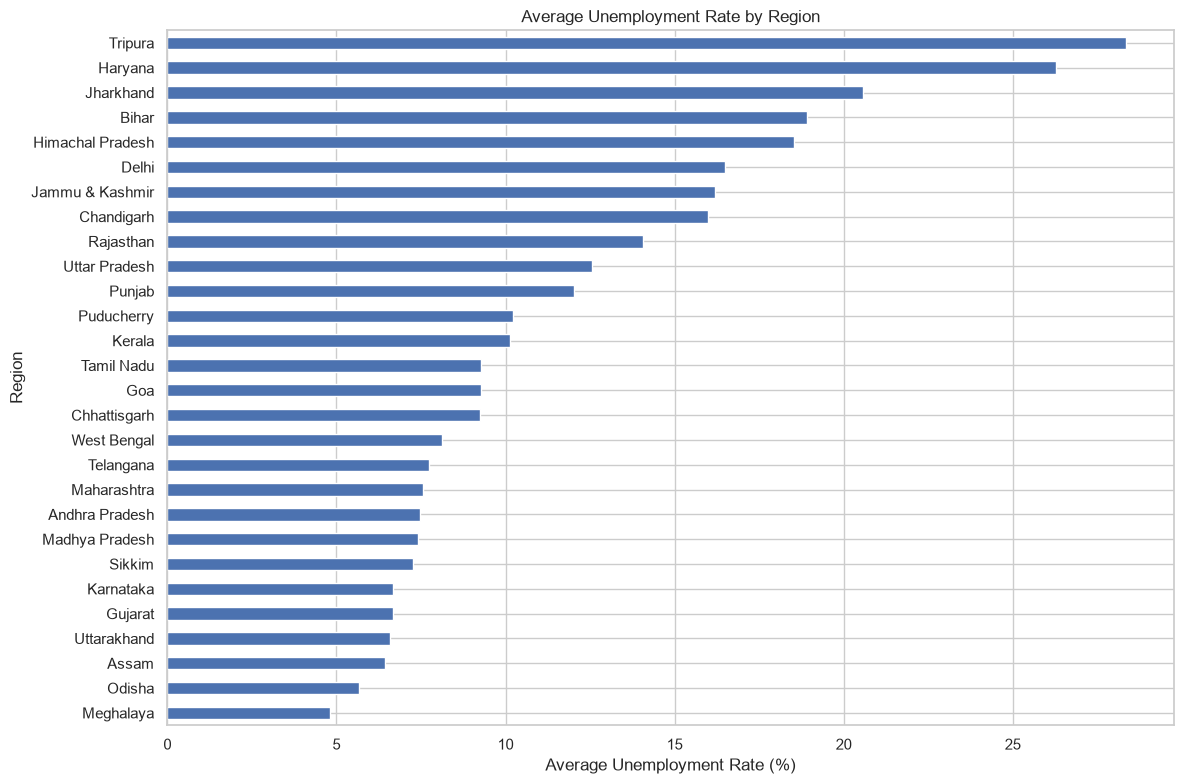

In [49]:
plt.figure(figsize=(12, 8))

region_avg.sort_values().plot(kind="barh")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Observation

The region-wise analysis shows noticeable differences in average unemployment rates across India.

Some regions consistently experience higher average unemployment than others. These differences may be associated with variations in economic activity, employment opportunities, industrial development, and labour-market conditions.

The ranking should be interpreted as an exploratory comparison rather than evidence that one factor directly causes higher unemployment.

### Monthly Unemployment Trend

Next, we examine how unemployment changed over time by calculating the average unemployment rate for each month.

In [50]:
monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_index()
)

monthly_unemployment.head()

Date
2019-05-31    8.874259
2019-06-30    9.303333
2019-07-31    9.033889
2019-08-31    9.637925
2019-09-30    9.051731
Name: Estimated Unemployment Rate (%), dtype: float64

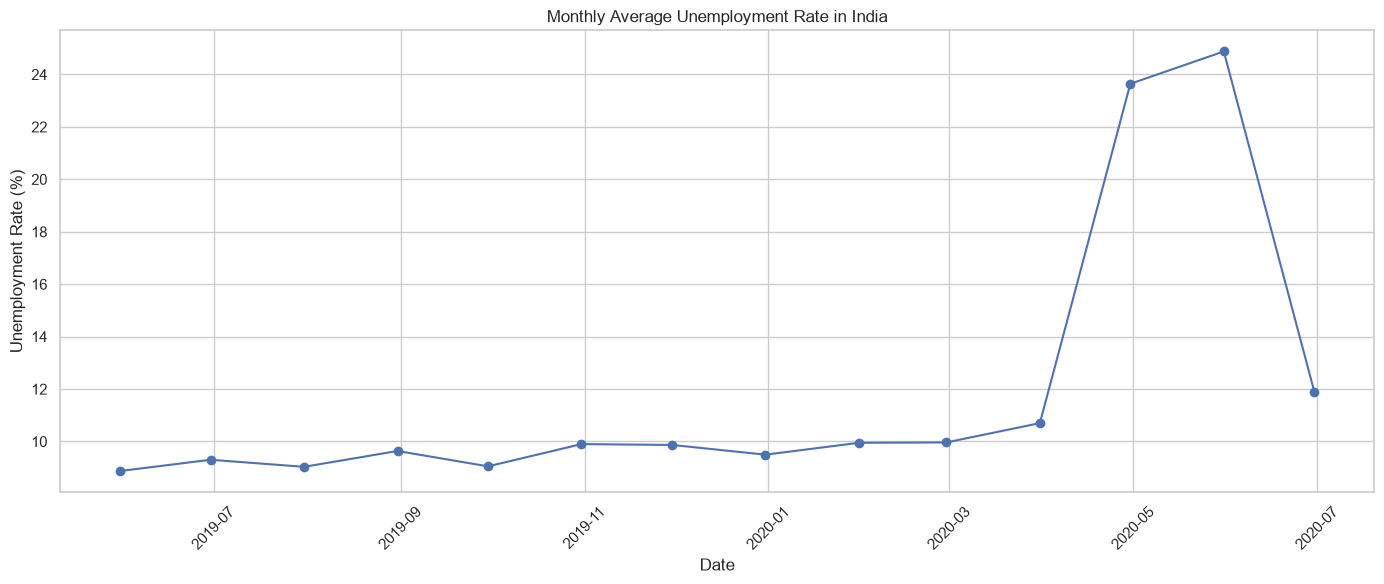

In [51]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker="o"
)

plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The monthly trend shows that unemployment fluctuated substantially over the observed period.

A particularly noticeable change occurs around the COVID-19 period, when economic activity and employment conditions were strongly disrupted.

The next analysis examines this period in more detail.

In [52]:
major_regions = [
    "Maharashtra",
    "Karnataka",
    "Tamil Nadu"
]

available_regions = [
    region for region in major_regions
    if region in df["Region"].unique()
]

print("Regions selected:", available_regions)

Regions selected: ['Maharashtra', 'Karnataka', 'Tamil Nadu']


### Unemployment Trends for Three Major Regions

We now compare unemployment trends over time for three major Indian states.

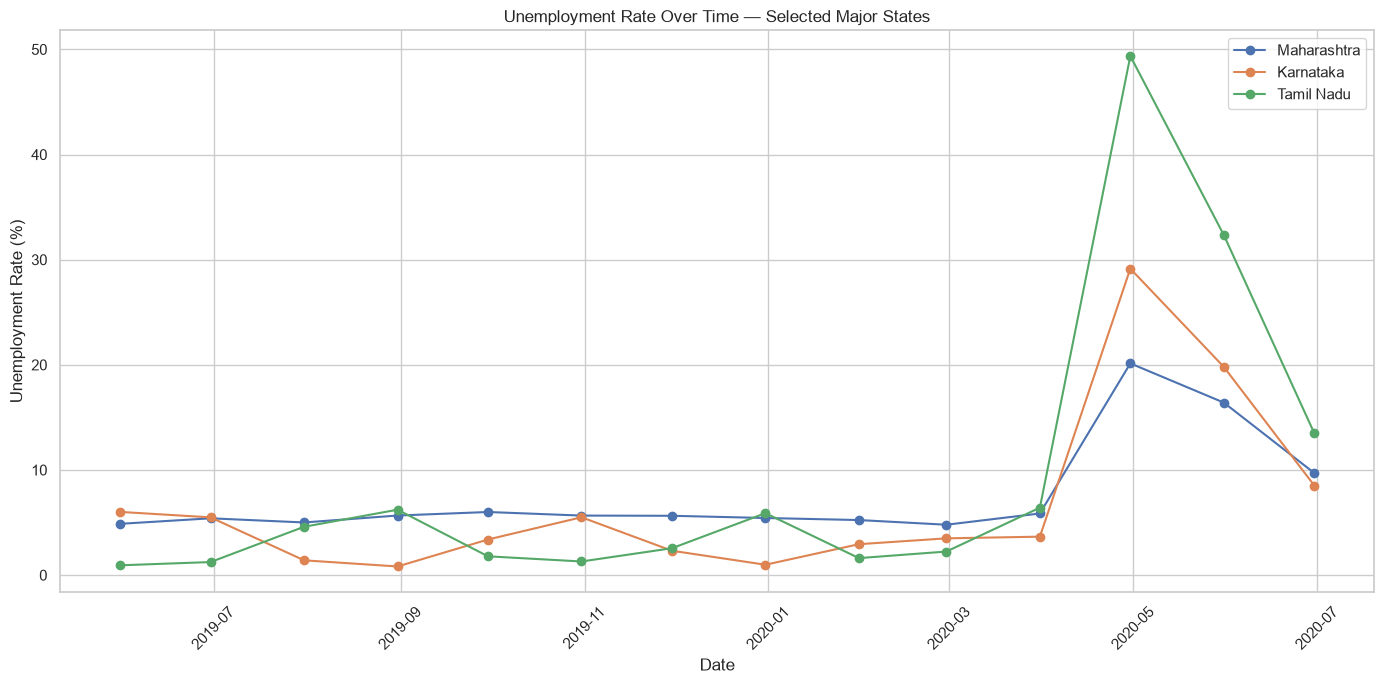

In [53]:
plt.figure(figsize=(14, 7))

for region in available_regions:
    
    region_data = (
        df[df["Region"] == region]
        .groupby("Date")["Estimated Unemployment Rate (%)"]
        .mean()
        .sort_index()
    )
    
    plt.plot(
        region_data.index,
        region_data.values,
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Over Time — Selected Major States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The three selected states show different unemployment patterns over time.

Although all regions experience fluctuations, the magnitude and timing of changes are not identical. This indicates that unemployment trends can vary considerably across regions even during the same national economic period.

## 4. Top 10 Regions by Average Unemployment

The following analysis identifies the ten regions with the highest average unemployment rates during the observed period.

In [54]:
top_10_regions = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10_regions

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

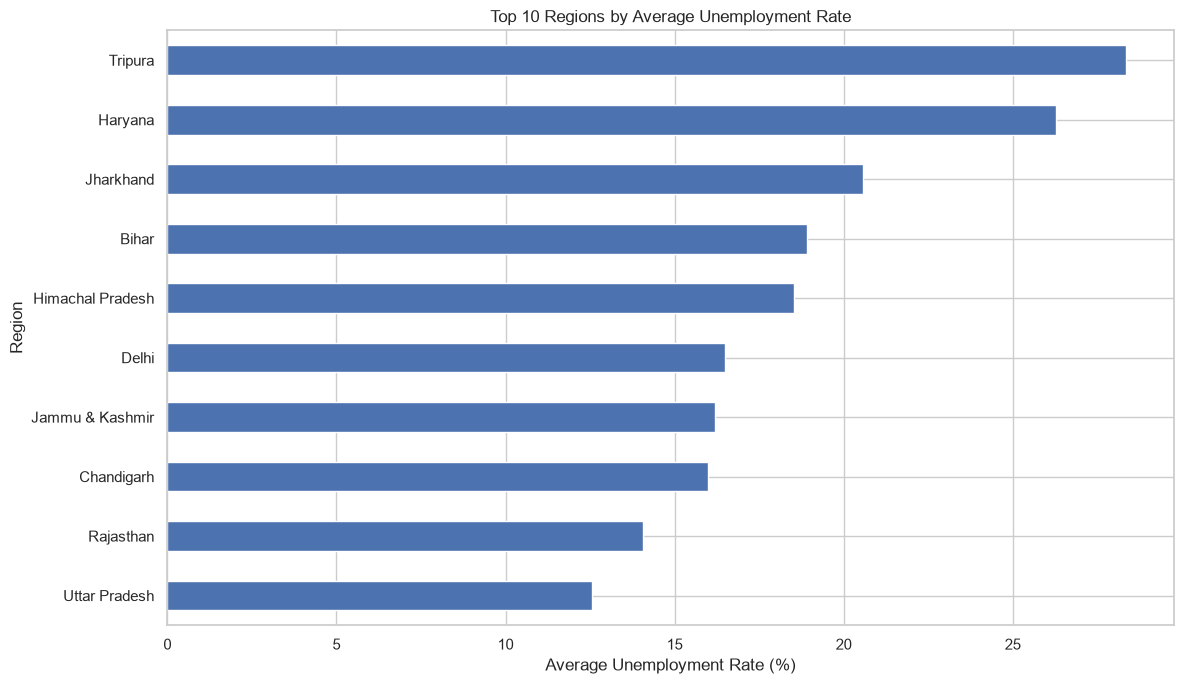

In [55]:
plt.figure(figsize=(12, 7))

top_10_regions.sort_values().plot(kind="barh")

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Observation

The top-10 comparison highlights the regions with the highest average unemployment rates in the dataset.

The differences between regions suggest that unemployment is not uniform across India. Regional economic structure, labour-market participation, industrial activity, and local employment opportunities can contribute to these differences.

In [56]:
df["Estimated Employment Rate (%)"] = (
    df["Estimated Labour Participation Rate (%)"]
    * (1 - df["Estimated Unemployment Rate (%)"] / 100)
)

df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employment Rate (%)",
        "Estimated Labour Participation Rate (%)"
    ]
].head()

,Estimated Unemployment Rate (%),Estimated Employment Rate (%),Estimated Labour Participation Rate (%)
0,3.65,41.661740,43.24
1,3.05,40.767475,42.05
2,3.75,41.868750,43.50
3,3.32,42.510196,43.97
4,5.17,42.370044,44.68


## 5. Correlation Analysis

Correlation analysis helps us understand the relationships between unemployment, employment, and labour participation.

A correlation close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship.

In [57]:
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employment Rate (%)",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employment Rate (%),Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.541232,0.002558
Estimated Employment Rate (%),-0.541232,1.000000,0.829870
Estimated Labour Participation Rate (%),0.002558,0.829870,1.000000


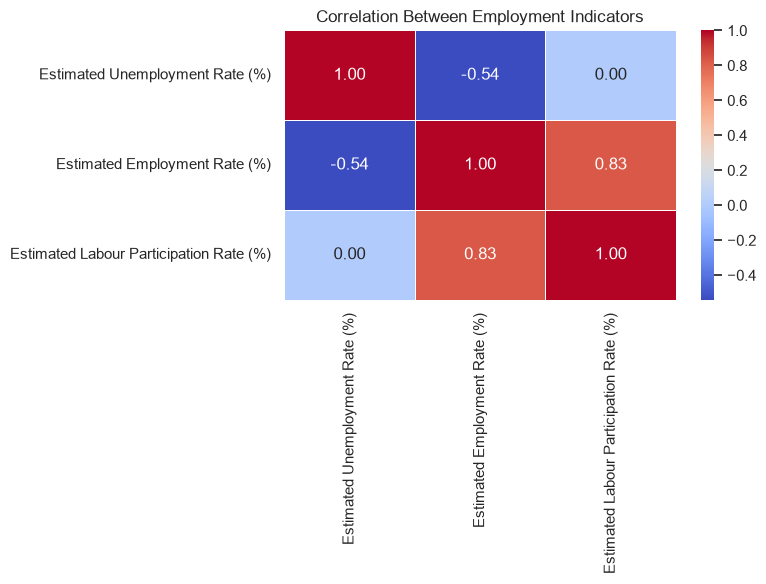

In [58]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Employment Indicators")

plt.tight_layout()
plt.show()

### Observation

The correlation matrix shows the relationships between unemployment, employment, and labour participation.

Unemployment and the derived employment rate are expected to show a negative relationship because higher unemployment generally corresponds to a lower proportion of the population being employed, given the same labour participation rate.

The heatmap describes association between variables and should not be interpreted as proof of causation.

## 6. Pre-COVID vs Post-COVID Analysis

To examine the impact of the COVID-19 period, the data is divided into two periods:

- Pre-COVID: before March 2020
- Post-COVID: March 2020 onward

We compare the average unemployment, employment, and labour participation rates between the two periods.

In [59]:
covid_cutoff = pd.Timestamp("2020-03-01")

df["COVID Period"] = np.where(
    df["Date"] < covid_cutoff,
    "Pre-COVID",
    "Post-COVID"
)

df["COVID Period"].value_counts()

COVID Period
Pre-COVID     536
Post-COVID    204
Name: count, dtype: int64

In [60]:
period_comparison = (
    df.groupby("COVID Period")[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employment Rate (%)",
            "Estimated Labour Participation Rate (%)"
        ]
    ]
    .mean()
)

period_comparison

,Estimated Unemployment Rate (%),Estimated Employment Rate (%),Estimated Labour Participation Rate (%)
COVID Period,,,
Post-COVID,17.774363,32.414147,39.330049
Pre-COVID,9.509534,39.577426,43.886119


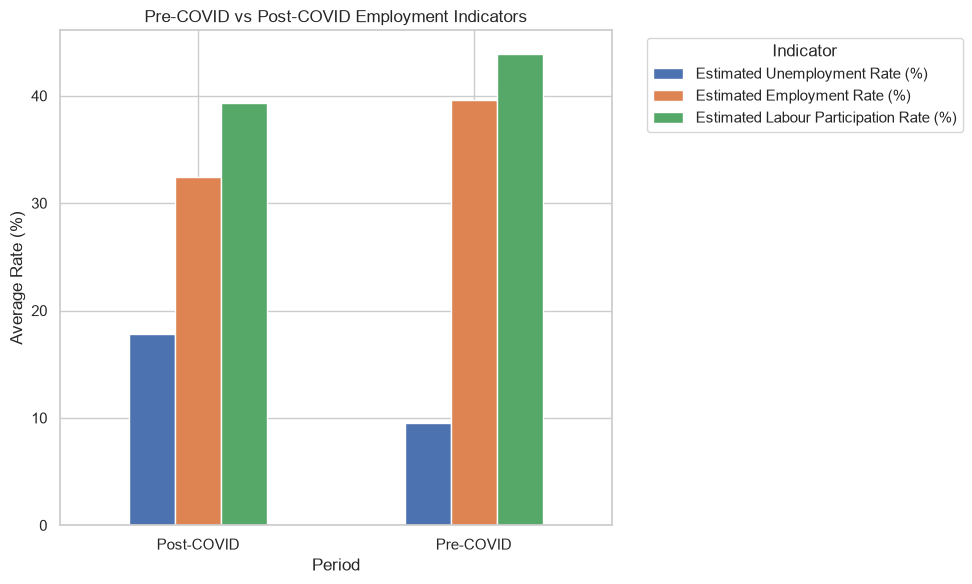

In [61]:
period_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Pre-COVID vs Post-COVID Employment Indicators")
plt.xlabel("Period")
plt.ylabel("Average Rate (%)")

plt.xticks(rotation=0)

plt.legend(
    title="Indicator",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Observation

The comparison between the two periods shows how unemployment and labour-market indicators changed around the COVID-19 period.

The post-COVID period should be interpreted in the context of the severe economic disruption caused by the pandemic and the subsequent recovery.

The exact magnitude of the change is determined by the averages calculated from this dataset.

## 7. Additional Insights

We identify the month with the highest average unemployment rate in the dataset.

In [62]:
highest_unemployment_date = monthly_unemployment.idxmax()
highest_unemployment_rate = monthly_unemployment.max()

print("Highest average unemployment month:", highest_unemployment_date.strftime("%B %Y"))
print("Highest average unemployment rate:", round(highest_unemployment_rate, 2), "%")

Highest average unemployment month: May 2020
Highest average unemployment rate: 24.88 %


In [63]:
lowest_unemployment_date = monthly_unemployment.idxmin()
lowest_unemployment_rate = monthly_unemployment.min()

print("Lowest average unemployment month:", lowest_unemployment_date.strftime("%B %Y"))
print("Lowest average unemployment rate:", round(lowest_unemployment_rate, 2), "%")

Lowest average unemployment month: May 2019
Lowest average unemployment rate: 8.87 %


# 8. Conclusion

This analysis explored unemployment trends in India using regional and temporal unemployment data.

### Key findings

1. Unemployment rates vary considerably across regions.
2. Monthly unemployment rates fluctuate over time.
3. Different states show different unemployment patterns.
4. The top-10 analysis highlights regions with relatively high average unemployment.
5. Employment and labour participation indicators show measurable relationships with unemployment.
6. The pre-COVID versus post-COVID comparison highlights significant changes in labour-market conditions during the pandemic period.
7. The COVID-19 period represents an important disruption in the unemployment trend.

Overall, the analysis demonstrates how exploratory data analysis and visualization can be used to understand regional and temporal labour-market patterns.

# 9. Project Summary

### Dataset
Unemployment in India dataset

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Analysis Performed
- Data cleaning
- Missing-value analysis
- Duplicate removal
- Data type conversion
- Descriptive statistics
- Region-wise unemployment analysis
- Monthly trend analysis
- State-wise time-series analysis
- Top-10 regional comparison
- Correlation analysis
- Pre-COVID vs Post-COVID comparison

### Conclusion
The analysis provides a data-driven view of unemployment patterns across Indian regions and over time, with particular attention to changes during the COVID-19 period.